In [1]:
# =========================================
# Common Initialization: Imports, Configurations, and Helper Functions
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Shared training state and alpha-equivalence accounting (root or NonStationary cwd).
import sys
import json
from pathlib import Path
import os
_root_candidates = ([Path(os.environ["LAST_MILE_PROJECT_ROOT"]).expanduser()]
                    if os.environ.get("LAST_MILE_PROJECT_ROOT") else [Path.cwd(), *Path.cwd().parents])
_support_root = next((p.resolve() for p in _root_candidates
                      if (p / "project_paths.py").is_file() and (p / "experiment.ipynb").is_file()), None)
if _support_root is None:
    raise FileNotFoundError("Start from this project or set LAST_MILE_PROJECT_ROOT to its folder")
if str(_support_root) not in sys.path:
    sys.path.insert(0, str(_support_root))
from experiment_support import (RolloutState, SWEEP_METADATA_COLUMNS, build_sweep_plan,
                                summarize_alpha_groups, with_effective_alpha,
                                best_equivalent_alpha_rate)
# Scenario paths are independent of the Jupyter working directory.
from project_paths import ProjectPaths, select_training_log, read_run_training_log
paths = ProjectPaths("nonstationary")
PROJECT_ROOT = paths.root
RESULTS_DIR = paths.results_dir
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
results_path = paths.results
result_file = paths.result_file
output_file = paths.output_file

# Only for historical CSVs without geometry metadata; use the parameters of that run.
# New result rows carry R/V/DT and do not use this fallback.
LEGACY_GEOMETRY = {"R": 5.5, "V": 0.19, "DT": 0.5}
from pathlib import Path

# ---------- Global Parameters ----------
CSV_PATH = results_path("param_sweep_results_2.csv") #For the full parameter test with lambda=40 and all alpha, use param_sweep_results_2_full_param.csv

# Color definitions
COLOR_SWITCH = "#1a80bb"   # HVOR (Switching) blue
COLOR_PURE   = "#ea801c"   # PURE_OR orange
COLOR_SOLID  = "#1a80bb"   # Solid line color
COLOR_DASHED = "#000000"   # Dashed line color

# Line style definitions
DASH_DOT = (0, (6, 2, 1.5, 2))  # dash-dot style
DASHED = (0, (6, 2))            # dashed style
# ----------------------------------------

# Paper-style matplotlib configuration
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

# Common helper function
def paper_axes(ax):
    """Make axes look paper-style: four borders, inward ticks, no grid."""
    ax.set_frame_on(True)
    for side in ("left", "right", "top", "bottom"):
        spine = ax.spines[side]
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_edgecolor("black")
        spine.set_position(("outward", 0))
    ax.tick_params(which="both", direction="in", width=1.0, length=4,
                   top=True, right=True)
    ax.grid(False)



def read_training_log(path):
    import csv
    rows = []
    with open(path, newline='') as f:
        r = csv.reader(f)
        header = next(r, [])
        if not header:
            return pd.DataFrame()
        for row in r:
            if len(row) > len(header):
                header.extend([f'extra_{i}' for i in range(len(header)+1, len(row)+1)])
            if len(row) < len(header):
                row = row + [''] * (len(header) - len(row))
            rows.append(row)
    df = pd.DataFrame(rows, columns=header)
    num_cols = [
        'update','reward','rate','ep_rate','terminal_time_min','steps','episodes',
        'step_avg_reward','step_avg_rate','LAMBDA','GAMMA_PACK','R_PICK_ALPHA',
        'RIDE_TTL_MIN','MAX_VISIBLE_RIDES','SWITCH_GRACE_STEPS','RT','combo_id'
    ]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    if 'kind' not in df.columns:
        df['kind'] = 'train'
    return df

# R_PICK_ALPHA and ALPHA_EFFECTIVE use code units; paper alpha = code alpha / sqrt(2).



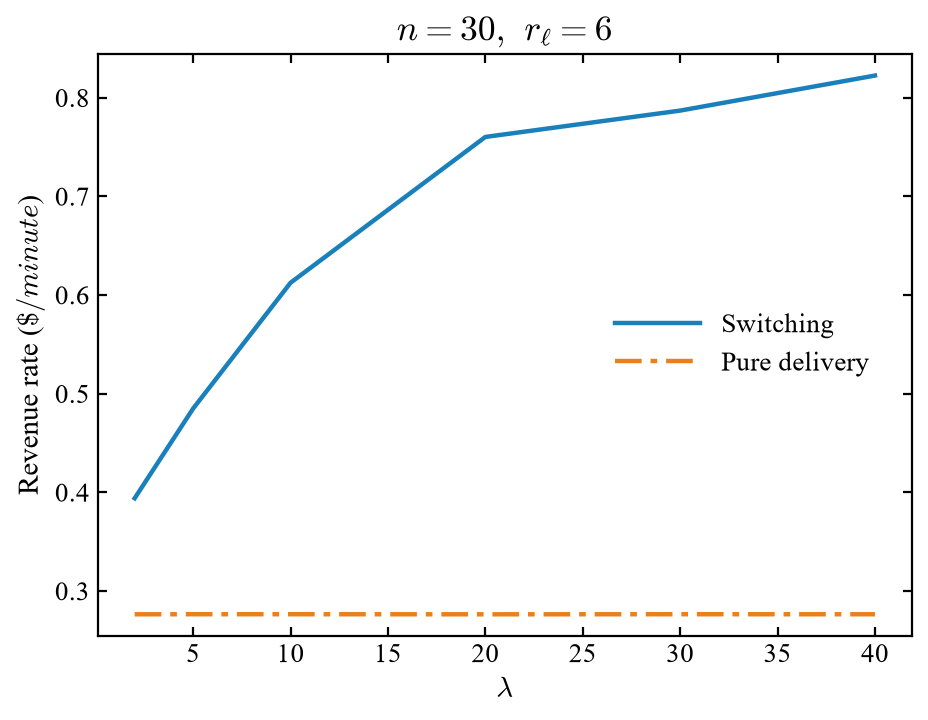

Saved: C:\Users\93541\Research_project\Last-mile Logistics\NonStationary\Results\rev_rate_vs_lambda_n30.png


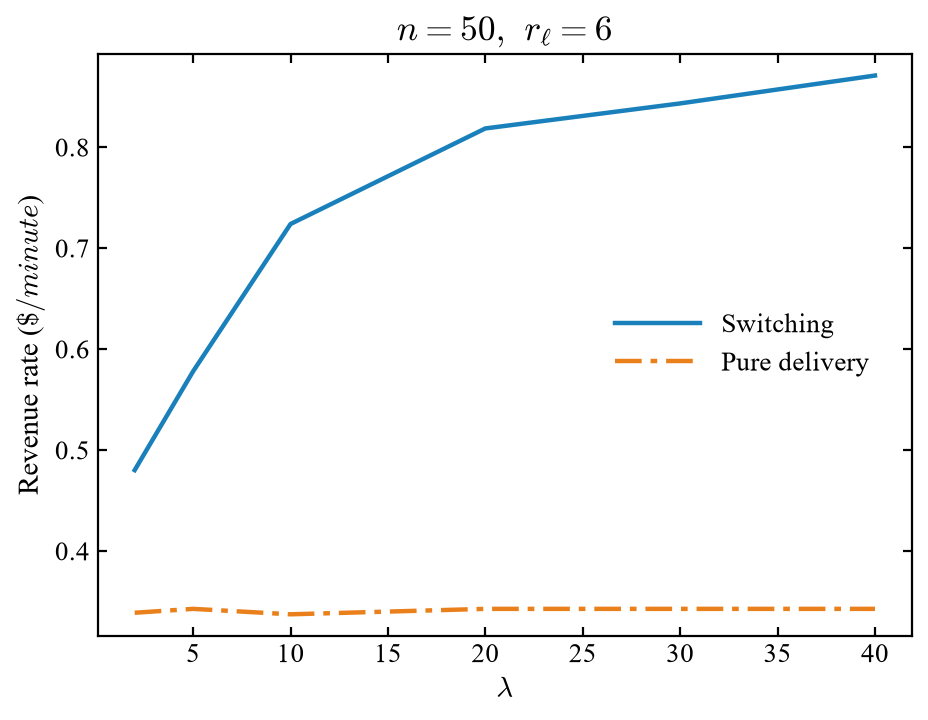

Saved: C:\Users\93541\Research_project\Last-mile Logistics\NonStationary\Results\rev_rate_vs_lambda_n50.png


In [2]:

# =========================================
# Paper-style: Revenue rate vs λ (two separate plots)
# =========================================

def best_alpha_series(df_in: pd.DataFrame, gamma_val, algo_name):
    """Average pure-delivery runs; optimize equivalent-alpha means for ride policies."""
    sub = df_in[(df_in["GAMMA_PACK"] == gamma_val) & (df_in["algo"] == algo_name)]
    if sub.empty:
        return np.array([]), np.array([])
    if algo_name in {"PURE", "PURE_OR"}:
        rates = sub.groupby("LAMBDA")["rate"].mean().sort_index()
        return rates.index.to_numpy(), rates.to_numpy()
    xs, ys = [], []
    for lam, group in sub.groupby("LAMBDA", sort=True):
        xs.append(lam)
        ys.append(best_equivalent_alpha_rate(group, legacy_geometry=LEGACY_GEOMETRY))
    return np.asarray(xs), np.asarray(ys)

# Load and filter data
df = pd.read_csv(CSV_PATH)
df = df[df["RT"] == 6.0].copy()
df = df[df["algo"].isin(["HEUR_VOR", "PURE_OR"])].copy()

# Two separate plots: n=30→γ≈0.50, n=50→γ≈0.83
PANELS = [
    {"title": r"$n=30,\ r_\ell=6$", "gamma": 0.50, "filename": results_path("rev_rate_vs_lambda_n30.png")},
    {"title": r"$n=50,\ r_\ell=6$", "gamma": 0.83, "filename": results_path("rev_rate_vs_lambda_n50.png")},
]

for p in PANELS:
    g = p["gamma"]
    
    # Create single plot
    fig, ax = plt.subplots(1, 1, figsize=(5.9, 4.6), dpi=160)

    # Get data (optimal α for each λ)
    lam_h, rate_h = best_alpha_series(df, g, "HEUR_VOR")
    lam_p, rate_p = best_alpha_series(df, g, "PURE_OR")

    # Plot lines
    if lam_h.size:
        ax.plot(lam_h, rate_h, color=COLOR_SWITCH, lw=2.0, label="Switching")
    if lam_p.size:
        ax.plot(lam_p, rate_p, color=COLOR_PURE, lw=2.0, linestyle=DASH_DOT,
                label="Pure delivery")

    # Axis styling
    paper_axes(ax)
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"Revenue rate ($\$/minute$)")
    ax.set_title(p["title"])

    # Legend: inside right, no frame, longer lines
    ax.legend(loc="center right", frameon=False, handlelength=3.2,
              borderaxespad=1.2)

    # Set reasonable y margin to avoid top edge
    y_candidates = []
    if rate_h.size: y_candidates += [rate_h.min(), rate_h.max()]
    if rate_p.size: y_candidates += [rate_p.min(), rate_p.max()]
    if y_candidates:
        ylo, yhi = min(y_candidates), max(y_candidates)
        pad = max(0.01, 0.04 * (yhi - ylo))
        ax.set_ylim(ylo - pad, yhi + pad)

    fig.tight_layout()
    plt.show()
    
    # Save figure
    fig.savefig(p["filename"], dpi=300, bbox_inches="tight")
    print(f"Saved: {p['filename']}")

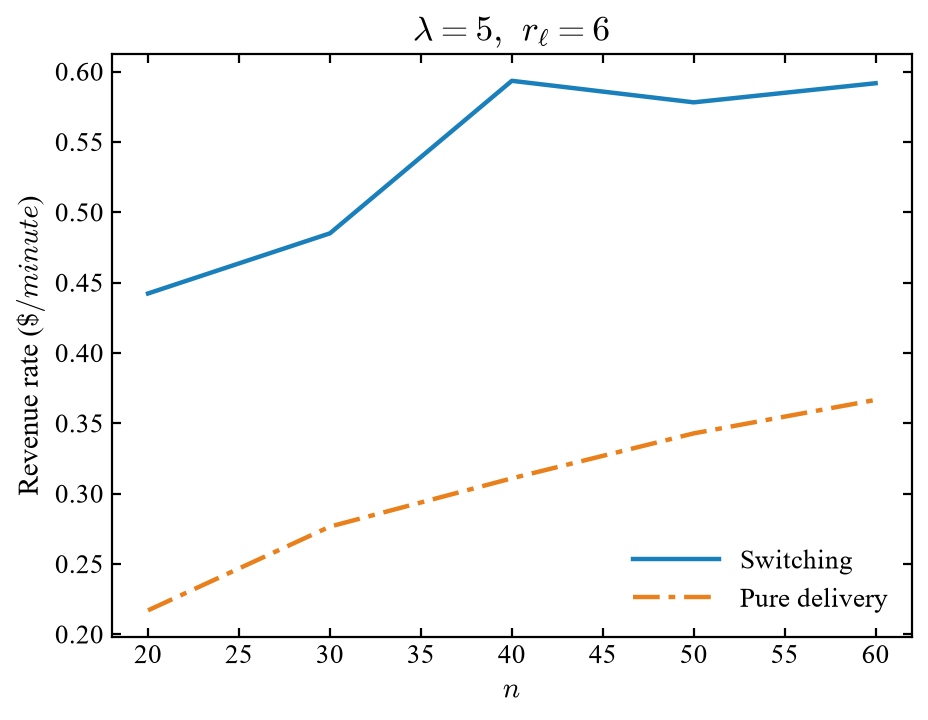

Saved: C:\Users\93541\Research_project\Last-mile Logistics\NonStationary\Results\rev_rate_vs_n_lambda5.png


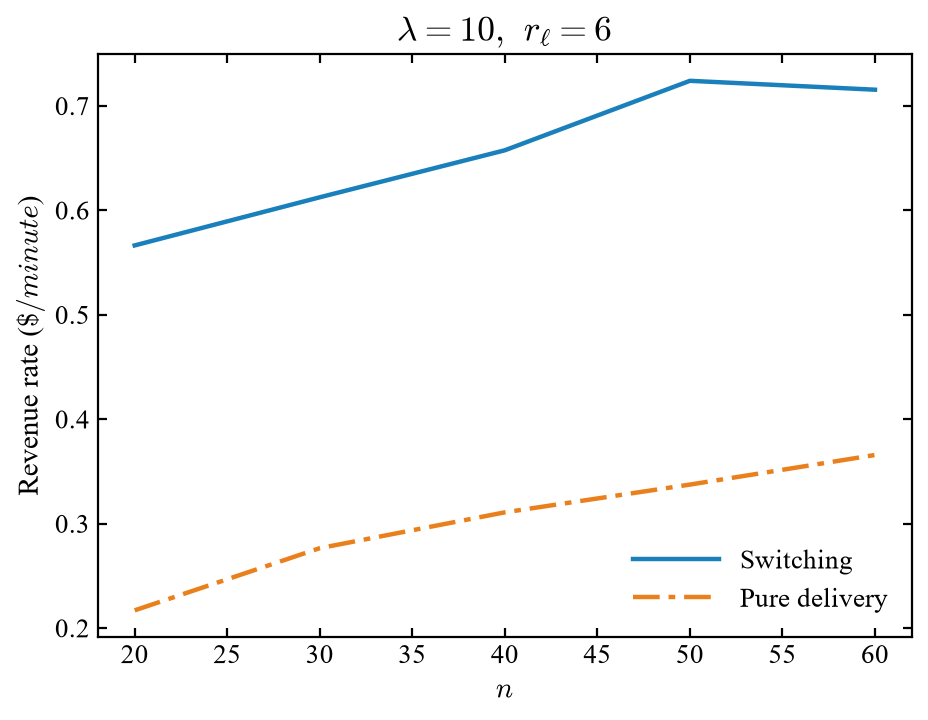

Saved: C:\Users\93541\Research_project\Last-mile Logistics\NonStationary\Results\rev_rate_vs_n_lambda10.png


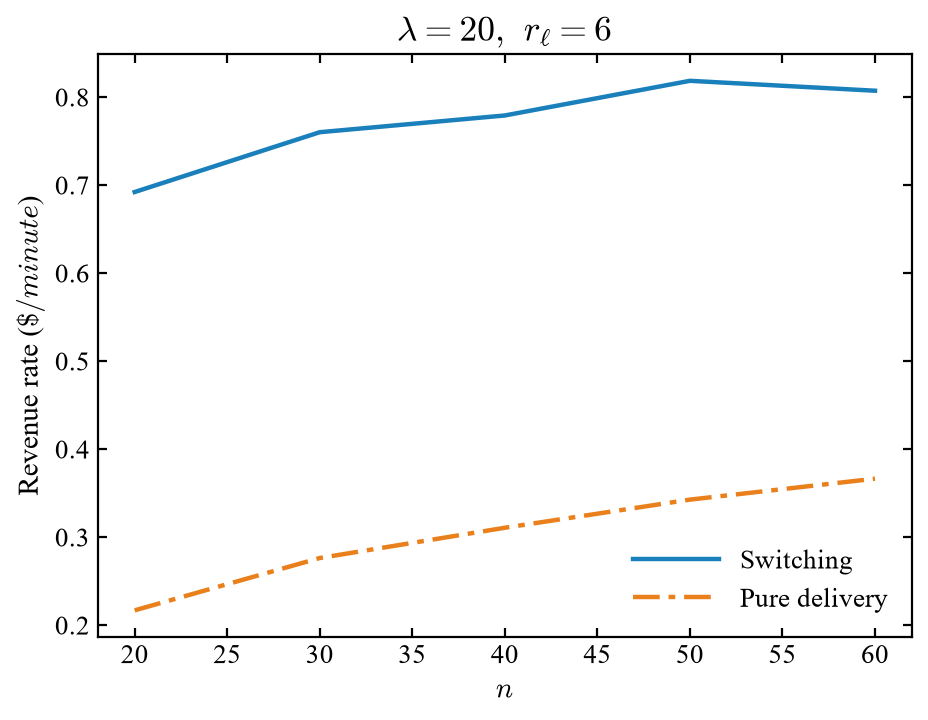

Saved: C:\Users\93541\Research_project\Last-mile Logistics\NonStationary\Results\rev_rate_vs_n_lambda20.png


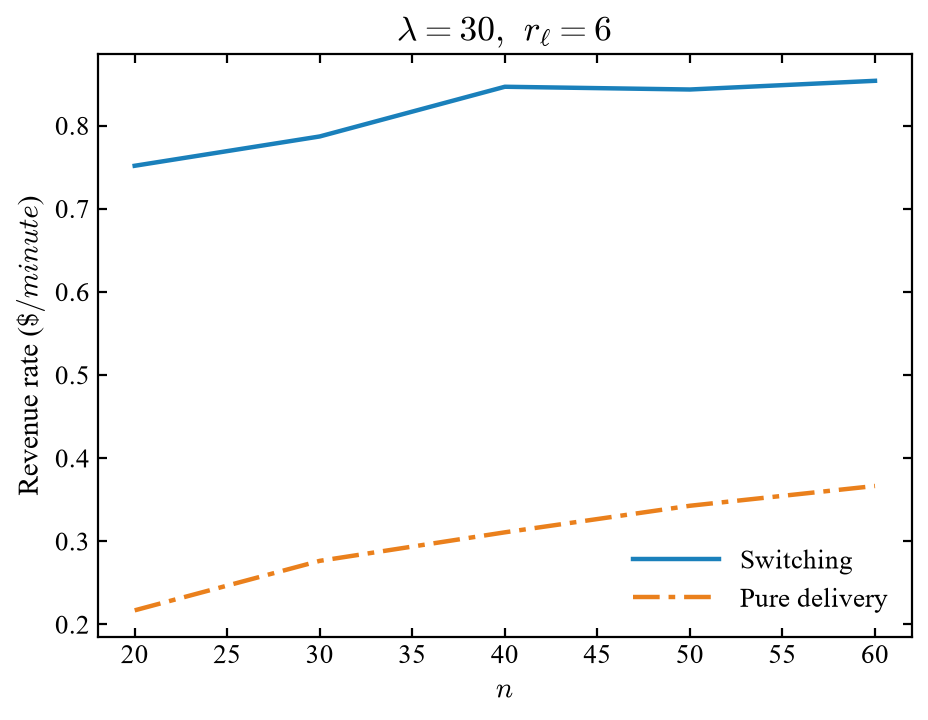

Saved: C:\Users\93541\Research_project\Last-mile Logistics\NonStationary\Results\rev_rate_vs_n_lambda30.png


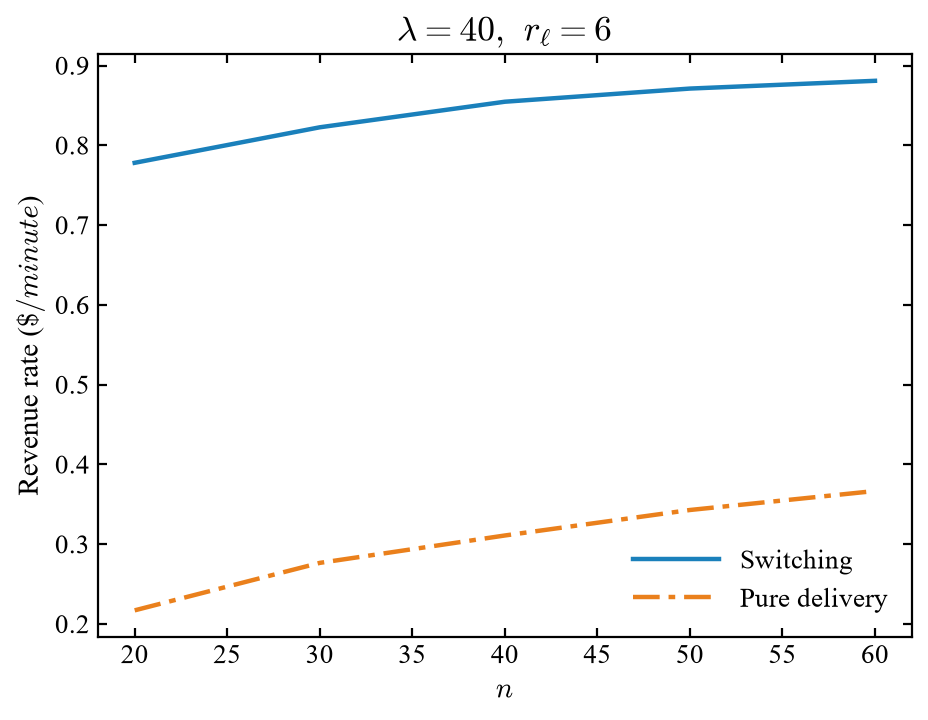

Saved: C:\Users\93541\Research_project\Last-mile Logistics\NonStationary\Results\rev_rate_vs_n_lambda40.png


In [3]:
# =========================================
# Paper-style: Revenue rate vs n (two separate plots for λ)
# =========================================

RT_FILTER = 6.0
R_ELL = f"{RT_FILTER:g}"  # r_ℓ for display
LAMBDAS = [5, 10, 20, 30, 40]  # Lambda values for panels
RATE_COL = "rate"  # Main metric: avg_rate = sum(reward) / sum(terminal_time); ep_rate is diagnostic only.

def best_alpha_by_lambda_gamma(df_in: pd.DataFrame, lam, gamma, algo):
    """Select group means within fixed scenarios; pure delivery retains run averaging."""
    sub = df_in[(df_in["LAMBDA"] == lam) &
                (df_in["GAMMA_PACK"] == gamma) & (df_in["algo"] == algo)]
    if sub.empty:
        return np.nan
    if algo in {"PURE", "PURE_OR"}:
        return float(sub[RATE_COL].mean())
    return best_equivalent_alpha_rate(sub, rate_col=RATE_COL, legacy_geometry=LEGACY_GEOMETRY)

# Load data, keep only the two required curves
df = pd.read_csv(CSV_PATH)
df = df[df["RT"] == RT_FILTER].copy()
df = df[df["algo"].isin(["HEUR_VOR", "PURE_OR"])].copy()

# γ to n conversion (n ≈ 60*γ)
GAMMAS = [0.33, 0.50, 0.67, 0.83, 1.00]
N_LIST = [int(round(g*60)) for g in GAMMAS]  # -> [20,30,40,50,60]

for lam in LAMBDAS:
    # Create single plot
    fig, ax = plt.subplots(1, 1, figsize=(5.9, 4.6), dpi=160)
    
    # Get optimal α rate for each n (corresponding γ)
    rate_hvor = []
    rate_puro = []
    for g in GAMMAS:
        rate_hvor.append(best_alpha_by_lambda_gamma(df, lam, g, "HEUR_VOR"))
        rate_puro.append(best_alpha_by_lambda_gamma(df, lam, g, "PURE_OR"))

    # Plot lines
    ax.plot(N_LIST, rate_hvor, color=COLOR_SWITCH, lw=2.0, label="Switching")
    ax.plot(N_LIST, rate_puro, color=COLOR_PURE, lw=2.0, linestyle=DASH_DOT, label="Pure delivery")

    # Axis styling and labels
    paper_axes(ax)
    ax.set_xlabel(r"$n$")
    ax.set_ylabel(r"Revenue rate ($\$/minute$)")
    ax.set_title(rf"$\lambda={lam},\ r_\ell={R_ELL}$")

    # Legend: inside lower right, no frame
    ax.legend(loc="lower right", frameon=False, handlelength=3.2)

    # Set appropriate padding
    y_all = [v for v in rate_hvor + rate_puro if np.isfinite(v)]
    if y_all:
        ylo, yhi = min(y_all), max(y_all)
        pad = max(0.01, 0.05*(yhi - ylo if yhi > ylo else 0.2))
        ax.set_ylim(ylo - pad, yhi + pad)

    fig.tight_layout()
    plt.show()
    
    # Save figure
    filename = results_path(f"rev_rate_vs_n_lambda{lam}.png")
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Saved: {filename}")

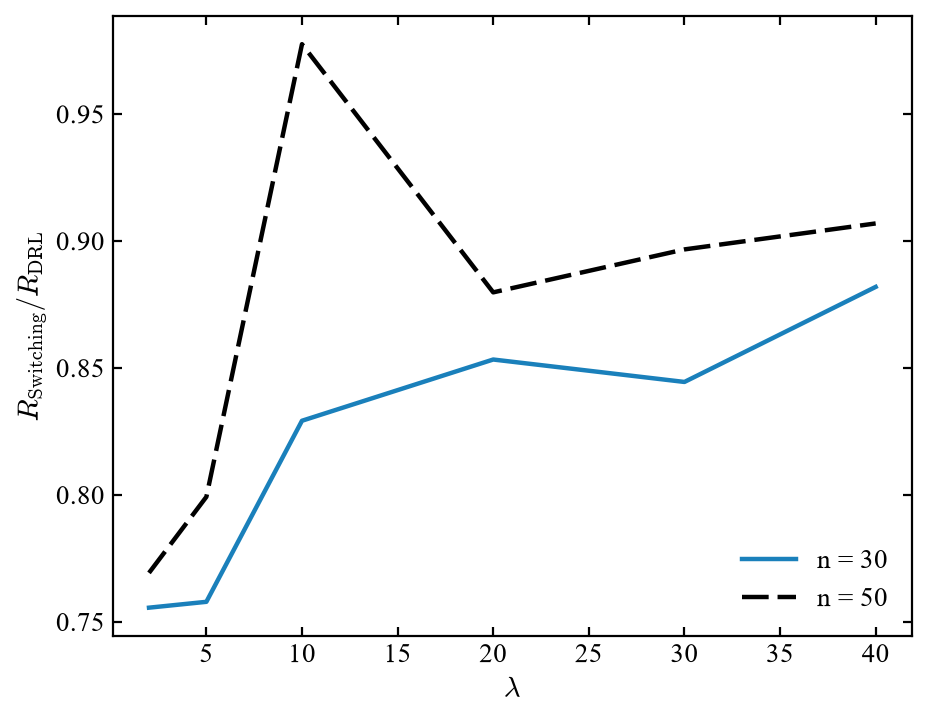

Saved: C:\Users\93541\Research_project\Last-mile Logistics\NonStationary\Results\ratio_hvor_drl_vs_lambda.png


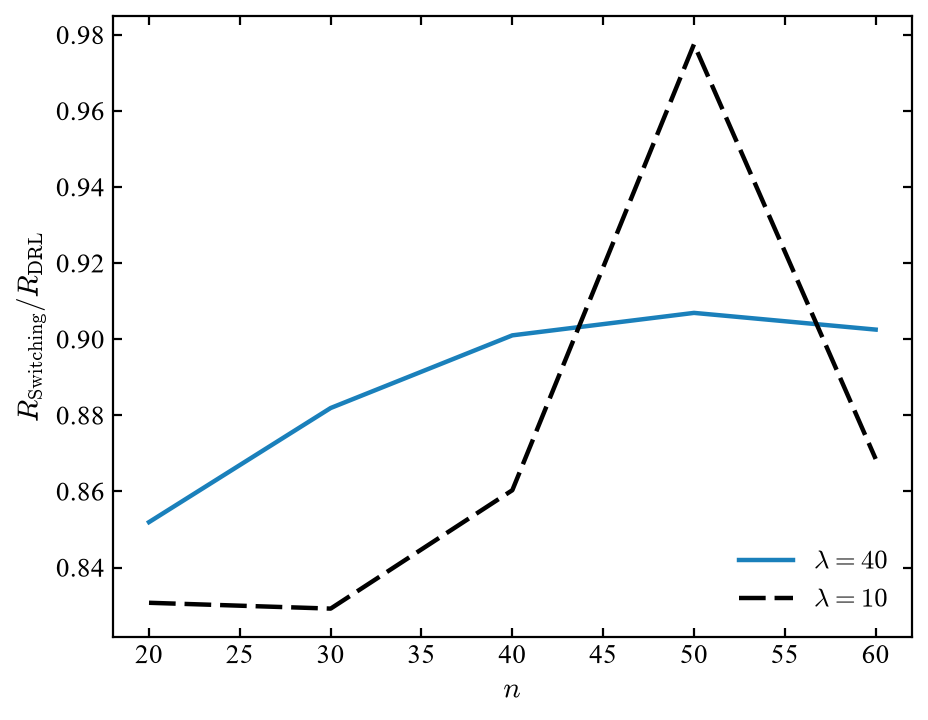

Saved: C:\Users\93541\Research_project\Last-mile Logistics\NonStationary\Results\ratio_hvor_drl_vs_n.png


In [4]:
# =========================================
# Paper-style: Ratio HVOR/DRL vs λ and vs n (two separate plots)
# =========================================

RT_FILTER = 6.0  # Only use results with r_ℓ = 6
LAM_LOW, LAM_HIGH = 10, 40  # Low/high λ for right plot
RATE_COL = "rate"  # Main metric: avg_rate = sum(reward) / sum(terminal_time); ep_rate is diagnostic only.

def best_alpha_rate(df_in, lam, gamma, algo):
    """Use the same equivalent-alpha selection for both sides of the policy ratio."""
    sub = df_in[(df_in["LAMBDA"] == lam) &
                (df_in["GAMMA_PACK"] == gamma) & (df_in["algo"] == algo)]
    if sub.empty:
        return np.nan
    if algo in {"PURE", "PURE_OR"}:
        return float(sub[RATE_COL].mean())
    return best_equivalent_alpha_rate(sub, rate_col=RATE_COL, legacy_geometry=LEGACY_GEOMETRY)

# Load and filter by r_ℓ, keep only DRL and HEUR_VOR
df = pd.read_csv(CSV_PATH)
df = df[df["RT"] == RT_FILTER]
df = df[df["algo"].isin(["DRL", "HEUR_VOR"])].copy()

# γ to n conversion (n ≈ 60*γ)
GAMMAS_ALL = sorted(df["GAMMA_PACK"].unique())
N_ALL = [int(round(g*60)) for g in GAMMAS_ALL]
gamma_of_n = {int(round(g*60)): g for g in GAMMAS_ALL}

# ---------- Plot 1: ratio vs λ (two curves: n=30, n=50) ----------
fig, ax = plt.subplots(1, 1, figsize=(5.9, 4.6), dpi=160)

lambda_vals = sorted(df["LAMBDA"].unique())
n_left_curves = [(30, COLOR_SOLID, "solid", "n = 30"),
                 (50, COLOR_DASHED, DASHED, "n = 50")]

for n_val, col, ls, lab in n_left_curves:
    g = gamma_of_n.get(n_val, None)
    if g is None:
        continue
    xs, ys = [], []
    for lam in lambda_vals:
        if lam < 2:  # Skip λ values less than 2
            continue
        hv = best_alpha_rate(df, lam, g, "HEUR_VOR")
        dr = best_alpha_rate(df, lam, g, "DRL")
        if np.isfinite(hv) and np.isfinite(dr) and dr > 0:
            xs.append(lam); ys.append(hv/dr)
    ax.plot(xs, ys, color=col, lw=2.0, linestyle=ls, label=lab)

paper_axes(ax)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$R_{\mathrm{Switching}}/R_{\mathrm{DRL}}$")
ax.legend(loc="lower right", frameon=False)

fig.tight_layout()
plt.show()

# Save figure
filename = results_path("ratio_hvor_drl_vs_lambda.png")
fig.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Saved: {filename}")

# ---------- Plot 2: ratio vs n (two curves: λ=40, λ=5) ----------
fig, ax = plt.subplots(1, 1, figsize=(5.9, 4.6), dpi=160)

lam_right_curves = [(LAM_HIGH, COLOR_SOLID, "solid", rf"$\lambda={LAM_HIGH}$"),
                    (LAM_LOW,  COLOR_DASHED, DASHED, rf"$\lambda={LAM_LOW}$")]

for lam, col, ls, lab in lam_right_curves:
    xs, ys = [], []
    for n_val in sorted(gamma_of_n.keys()):
        g = gamma_of_n[n_val]
        hv = best_alpha_rate(df, lam, g, "HEUR_VOR")
        dr = best_alpha_rate(df, lam, g, "DRL")
        if np.isfinite(hv) and np.isfinite(dr) and dr > 0:
            xs.append(n_val); ys.append(hv/dr)
    ax.plot(xs, ys, color=col, lw=2.0, linestyle=ls, label=lab)

paper_axes(ax)
ax.set_xlabel(r"$n$")
ax.set_ylabel(r"$R_{\mathrm{Switching}}/R_{\mathrm{DRL}}$")
ax.legend(loc="lower right", frameon=False)

fig.tight_layout()
plt.show()

# Save figure
filename = results_path("ratio_hvor_drl_vs_n.png")
fig.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Saved: {filename}")

Convergence: run_id=20260927T095930443635Z_577f21e5, combo_id=180, train_seed=42
Log: C:\Users\93541\Research_project\Last-mile Logistics\NonStationary\Results\param_sweep_results_2_runs\20260927T095930443635Z_577f21e5\combo_0180\training_log.csv


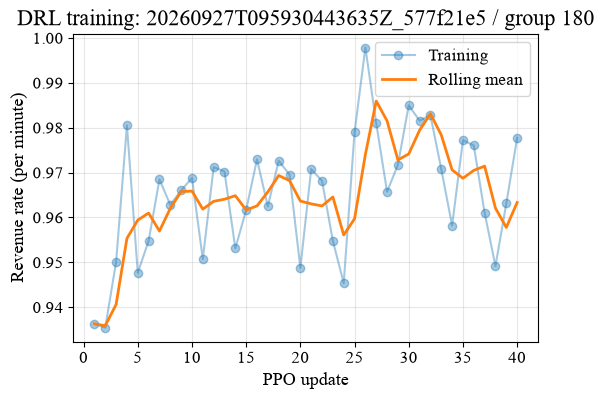

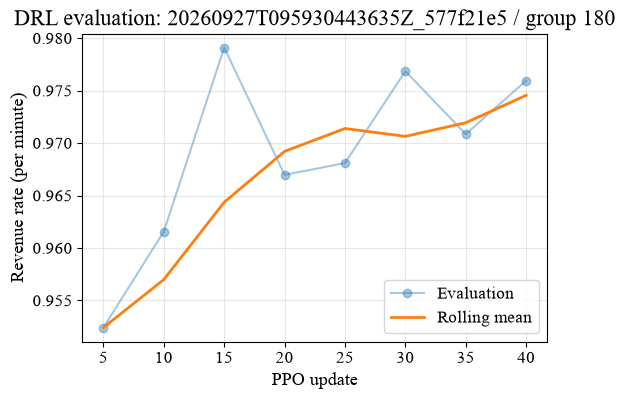

In [5]:
# DRL convergence for one explicitly identified run/group.
# None selects the newest run with recorded data, then its latest logged group.
ANALYSIS_RUN_ID = None
ANALYSIS_COMBO_ID = None
ANALYSIS_RUN_DIR = None  # optional absolute path to a particular saved run

log_path, selected_run_id, selected_combo_id = select_training_log(
    CSV_PATH, run_id=ANALYSIS_RUN_ID, combo_id=ANALYSIS_COMBO_ID, run_dir=ANALYSIS_RUN_DIR)
df = read_run_training_log(log_path, run_id=selected_run_id, combo_id=selected_combo_id)
print(f"Convergence: run_id={selected_run_id}, combo_id={selected_combo_id}, "
      f"train_seed={df['train_seed'].iloc[0]}\nLog: {log_path}")

# Identity is validated before smoothing; unrelated runs are never averaged.
units = 'Revenue rate (per minute)'
if 'REPORT_UNSCALED' in df and str(df['REPORT_UNSCALED'].iloc[0]).lower() in ('false', '0', '0.0'):
    units = 'Revenue rate (scaled, per minute)'
for kind, column, label in [('train', 'step_avg_rate', 'Training'), ('eval', 'rate', 'Evaluation')]:
    curve = df.loc[df['kind'] == kind, ['update', column]].sort_values('update').copy()
    if curve.empty:
        continue
    curve['smooth'] = curve[column].rolling(window=3, min_periods=1).mean()
    plt.figure(figsize=(6, 4))
    plt.plot(curve['update'], curve[column], marker='o', alpha=0.4, label=label)
    plt.plot(curve['update'], curve['smooth'], linewidth=2, label='Rolling mean')
    plt.xlabel('PPO update')
    plt.ylabel(units)
    plt.title(f'DRL {label.lower()}: {selected_run_id} / group {selected_combo_id}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


In [6]:
# The comparison of the average terminal time between algorithms

# Load the dataset
csv_path = results_path('param_sweep_results_2.csv')
df = pd.read_csv(result_file(csv_path))

# Filter for HEUR and HEUR_VOR algorithms
heur_df = df[df['algo'].isin(['DRL', 'HEUR', 'HEUR_VOR', 'PURE', 'PURE_OR'])]

# Calculate and print the mean terminal_time for each
mean_terminal_time = heur_df.groupby('algo')['terminal_time'].mean()

print("Average Terminal Time Comparison:")
print(mean_terminal_time)



Average Terminal Time Comparison:
algo
DRL         3769.181667
HEUR        2281.282222
HEUR_VOR    1106.113333
PURE         323.160000
PURE_OR      272.185000
Name: terminal_time, dtype: float64


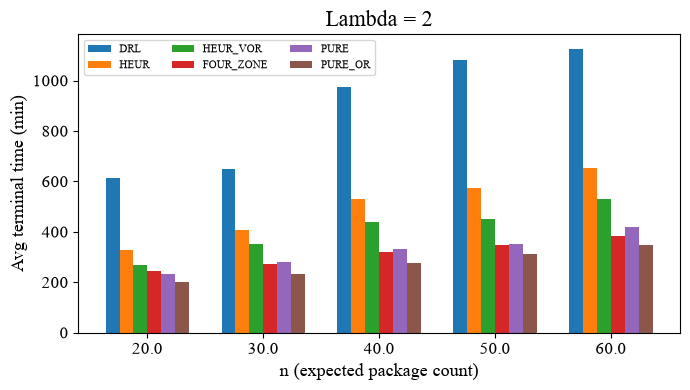

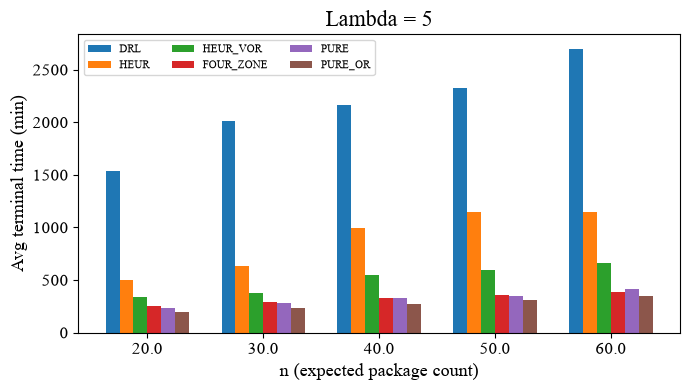

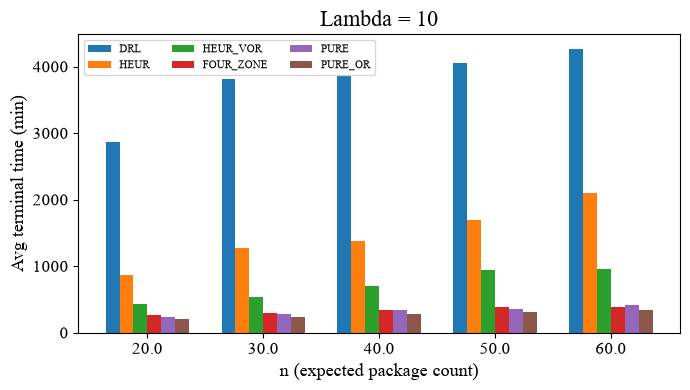

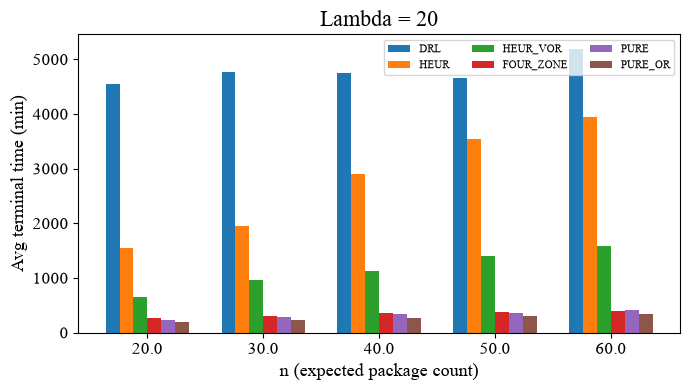

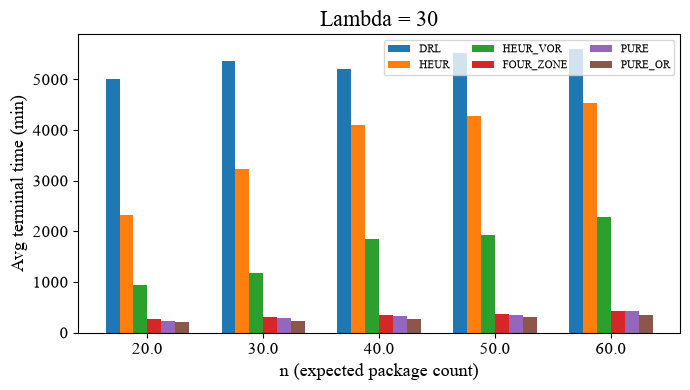

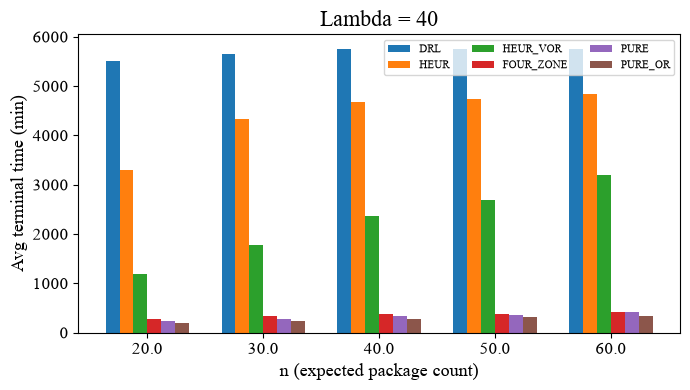

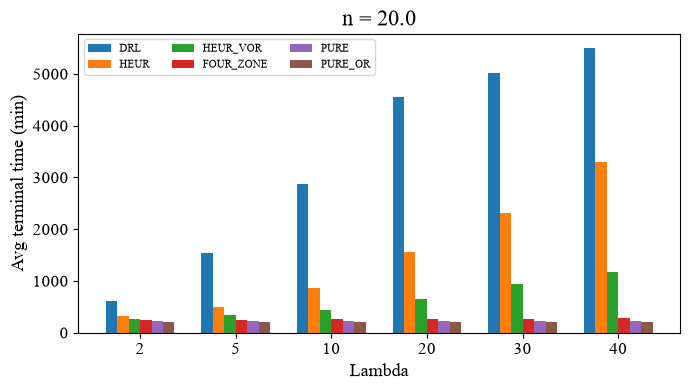

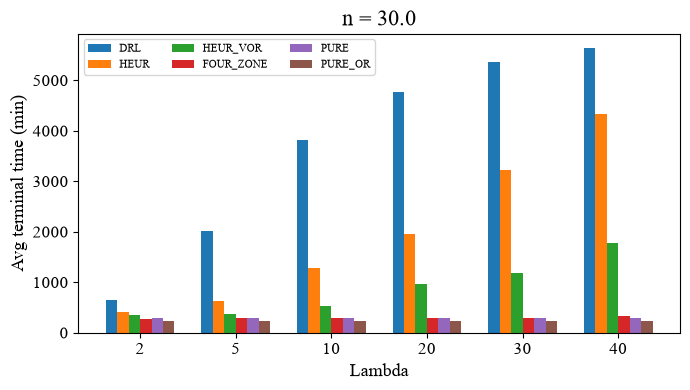

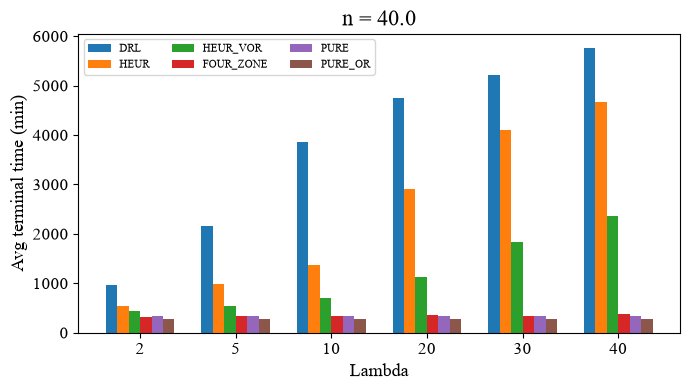

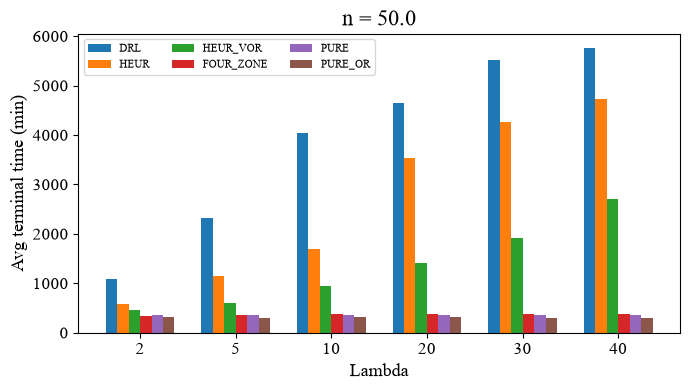

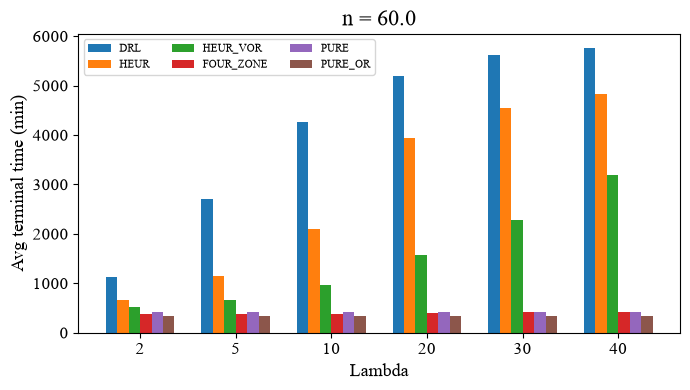

In [7]:

# =========================================
# Avg terminal time by n/lambda (grouped bar charts)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = results_path('param_sweep_results_2.csv')
df = pd.read_csv(result_file(csv_path))
R_val = 5.5
df['n_est'] = df['GAMMA_PACK'] * (2 * (R_val ** 2))
# round n to nearest {20,30,40,50,60}
targets = np.array([20, 30, 40, 50, 60], dtype=float)
df['n_round'] = df['n_est'].apply(lambda x: targets[np.argmin(np.abs(targets - x))])

algos = ['DRL','HEUR','HEUR_VOR','FOUR_ZONE','PURE','PURE_OR']
df = df[df['algo'].isin(algos)].copy()

# --- By lambda: grouped bars over n ---
lambdas = sorted(df['LAMBDA'].unique())
for lam in lambdas:
    sub = df[df['LAMBDA'] == lam]
    grp = (sub.groupby(['algo','n_round'])['terminal_time']
             .mean()
             .reset_index())
    n_vals = sorted(grp['n_round'].unique())
    x = np.arange(len(n_vals))
    width = 0.12
    plt.figure(figsize=(7,4))
    for i, algo in enumerate(algos):
        sg = grp[grp['algo']==algo]
        y = [sg[sg['n_round']==n]['terminal_time'].values[0] if n in sg['n_round'].values else np.nan for n in n_vals]
        plt.bar(x + (i - len(algos)/2)*width + width/2, y, width=width, label=algo)
    plt.title(f'Lambda = {lam}')
    plt.xlabel('n (expected package count)')
    plt.ylabel('Avg terminal time (min)')
    plt.xticks(x, [f'{n:.1f}' for n in n_vals])
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()

# --- By n: grouped bars over lambda ---
n_levels = sorted(df['n_round'].unique())
for n in n_levels:
    sub = df[df['n_round'] == n]
    grp = (sub.groupby(['algo','LAMBDA'])['terminal_time']
             .mean()
             .reset_index())
    lam_vals = sorted(grp['LAMBDA'].unique())
    x = np.arange(len(lam_vals))
    width = 0.12
    plt.figure(figsize=(7,4))
    for i, algo in enumerate(algos):
        sg = grp[grp['algo']==algo]
        y = [sg[sg['LAMBDA']==lam]['terminal_time'].values[0] if lam in sg['LAMBDA'].values else np.nan for lam in lam_vals]
        plt.bar(x + (i - len(algos)/2)*width + width/2, y, width=width, label=algo)
    plt.title(f'n = {n:.1f}')
    plt.xlabel('Lambda')
    plt.ylabel('Avg terminal time (min)')
    plt.xticks(x, [str(l) for l in lam_vals])
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()


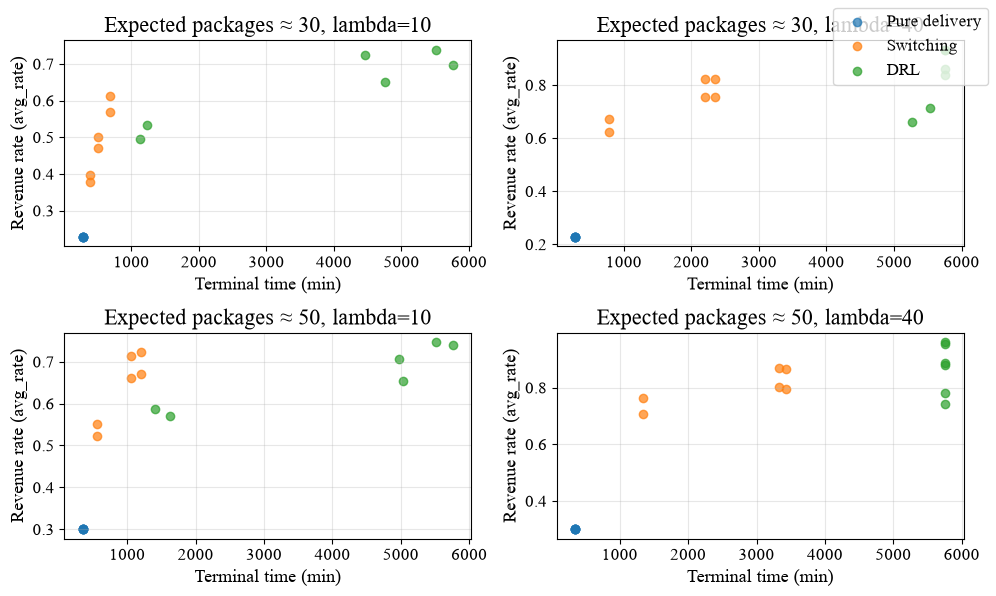

In [8]:
# =========================================
# Scatter: termination time vs revenue rate (n=30/50, lambda=10/40)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def select_scatter_package_sizes(df_in: pd.DataFrame) -> pd.DataFrame:
    """Select the gamma=.50/.83 settings (E[N]=30.25/50.215 for R=5.5).

    Panel labels 30 and 50 are approximate expected counts, not realized counts.
    Other package densities must not be rounded into these two groups.
    """
    gamma = df_in["GAMMA_PACK"].to_numpy(dtype=float)
    labels = np.select([np.isclose(gamma, .50, rtol=0, atol=1e-8),
                        np.isclose(gamma, .83, rtol=0, atol=1e-8)],
                       [30, 50], default=-1)
    keep = labels != -1
    selected = df_in.loc[keep].copy()
    selected["n_label"] = labels[keep]
    return selected


csv_path = results_path('param_sweep_results_2.csv')
df = pd.read_csv(result_file(csv_path))
R_val = 5.5
df['n_est'] = df['GAMMA_PACK'] * (2 * (R_val ** 2))
df = select_scatter_package_sizes(df)

policies = {'PURE':'Pure delivery', 'HEUR_VOR':'Switching', 'DRL':'DRL'}
lambdas = [10, 40]
n_levels = [30, 50]
RATE_COL = "rate"  # Main metric: avg_rate = sum(reward) / sum(terminal_time); ep_rate is diagnostic only.

fig, axes = plt.subplots(len(n_levels), len(lambdas), figsize=(10, 6), sharex=False, sharey=False)
for i, n in enumerate(n_levels):
    for j, lam in enumerate(lambdas):
        ax = axes[i][j] if len(n_levels) > 1 else axes[j]
        sub = df[(df['n_label'] == n) & (df['LAMBDA'] == lam) & (df['algo'].isin(policies.keys()))]
        for algo, label in policies.items():
            sg = sub[sub['algo'] == algo]
            ax.scatter(sg['terminal_time'], sg[RATE_COL], label=label, alpha=0.7)
        ax.set_title(f'Expected packages ≈ {n}, lambda={lam}')
        ax.set_xlabel('Terminal time (min)')
        ax.set_ylabel('Revenue rate (avg_rate)')
        ax.grid(True, alpha=0.3)
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.show()
